# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rimlazrek1/flyrank-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

**Score:** Lane 4 logistic model → `P(is_ctr_underperformer)`. Same March slice and features as ML-08/09. `ctr_gap` stays out of features (it leaks the label).

**Two columns, two jobs:**
- **Reason code** = how urgent (`high_visibility_ctr_gap` / `ctr_below_tier_median` / `general_ctr_monitor`)
- **Archetype** = what to do (maps to an action)

| Archetype | When | Action |
|---|---|---|
| `high_volume_ctr_gap` | imp ≥ 500, visible tier, CTR under tier median | `review_title_meta` |
| `zero_click_visible` | imp ≥ 500, visible tier, CTR = 0 | `check_tracking_first` |
| `deep_tier` | imp ≥ 500, page_3_5 / deep | `ranking_not_ctr` |
| `thin_volume` | imp < 500 | `monitor_only` |
| `healthy` | CTR at/above tier median | `no_action` |

Queue order: actionable first, then model score. Holdout metrics are the honest evidence; the full-portfolio score only sets the order.

In [17]:
import json
import os
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ROOT = Path.cwd()
while not (ROOT / "data" / "raw").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

try:
    from dotenv import load_dotenv
    load_dotenv(ROOT / ".env")
except ImportError:
    pass

HF_TOKEN = os.environ.get("HF_TOKEN")
if not HF_TOKEN:
    import getpass
    HF_TOKEN = getpass.getpass("HF READ token (hf_...): ")

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = "hf://datasets/FlyRank/internship-warehouse"
FACT_MAR = f"read_parquet('{REL}/fact_content_daily_performance/month=2026-03/*.parquet')"

LABEL = "is_ctr_underperformer"
FEATURE_COLS = ["imp_mar", "ctr_mar", "pos_avg_mar", "engagement_rate_mar", "position_tier"]
TIER_ORDER = ["top_3", "page_1", "striking", "page_3_5", "deep"]
IMP_FLOOR = 500
RANDOM_STATE = 42


def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores, dtype=float))
    k = min(k, len(order))
    return float(np.asarray(labels)[order[:k]].mean())


def make_pipeline():
    prep = ColumnTransformer(
        [
            ("num", StandardScaler(), ["imp_mar", "ctr_mar", "pos_avg_mar", "engagement_rate_mar"]),
            ("cat", OneHotEncoder(handle_unknown="ignore"), ["position_tier"]),
        ]
    )
    return Pipeline(
        [("prep", prep), ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]
    )


# Same March slice + label as ML-07/08/09. Half-month cols only for the decay check later.
features = con.sql(
    f"""
    WITH daily AS (
        SELECT
            client_hash_id, content_hash_id,
            SUM(gsc_impressions) AS imp_mar,
            SUM(gsc_clicks) AS clk_mar,
            AVG(NULLIF(gsc_avg_position, 0)) AS pos_avg_mar,
            SUM(CASE WHEN ga4_data_available IS TRUE THEN ga4_sessions ELSE 0 END) AS sessions_mar,
            SUM(CASE WHEN ga4_data_available IS TRUE THEN ga4_engaged_sessions ELSE 0 END) AS engaged_mar,
            SUM(CASE WHEN EXTRACT(DAY FROM report_date) <= 15 THEN gsc_impressions ELSE 0 END) AS imp_h1,
            SUM(CASE WHEN EXTRACT(DAY FROM report_date) <= 15 THEN gsc_clicks ELSE 0 END) AS clk_h1,
            AVG(CASE WHEN EXTRACT(DAY FROM report_date) <= 15 THEN NULLIF(gsc_avg_position, 0) END) AS pos_h1,
            SUM(CASE WHEN EXTRACT(DAY FROM report_date) > 15 THEN gsc_impressions ELSE 0 END) AS imp_h2,
            SUM(CASE WHEN EXTRACT(DAY FROM report_date) > 15 THEN gsc_clicks ELSE 0 END) AS clk_h2,
            AVG(CASE WHEN EXTRACT(DAY FROM report_date) > 15 THEN NULLIF(gsc_avg_position, 0) END) AS pos_h2
        FROM {FACT_MAR}
        GROUP BY 1, 2
        HAVING SUM(gsc_impressions) >= 100
    ),
    scored AS (
        SELECT *,
            CASE WHEN imp_mar > 0 THEN 100.0 * clk_mar / imp_mar END AS ctr_mar,
            CASE WHEN sessions_mar > 0 THEN 100.0 * engaged_mar / sessions_mar END AS engagement_rate_mar,
            CASE
                WHEN pos_avg_mar <= 3 THEN 'top_3'
                WHEN pos_avg_mar <= 10 THEN 'page_1'
                WHEN pos_avg_mar <= 20 THEN 'striking'
                WHEN pos_avg_mar <= 50 THEN 'page_3_5'
                ELSE 'deep'
            END AS position_tier
        FROM daily
        WHERE pos_avg_mar > 0
    )
    SELECT *,
        MEDIAN(ctr_mar) OVER (PARTITION BY position_tier) AS tier_median_ctr,
        CASE
            WHEN ctr_mar < MEDIAN(ctr_mar) OVER (PARTITION BY position_tier)
                 AND imp_mar >= {IMP_FLOOR}
            THEN 1 ELSE 0
        END AS is_ctr_underperformer
    FROM scored
"""
).df()

queue = features.dropna(subset=["ctr_mar", "pos_avg_mar"]).copy()
queue["engagement_rate_mar"] = queue["engagement_rate_mar"].fillna(0)
queue["ctr_gap"] = queue["tier_median_ctr"] - queue["ctr_mar"]  # baseline score only, never a feature
queue = queue.sort_values(["client_hash_id", "content_hash_id"]).reset_index(drop=True)

# Client holdout (honest metrics) + full refit (queue order only)
rng = np.random.default_rng(RANDOM_STATE)
clients = rng.permutation(np.sort(queue["client_hash_id"].unique()))
test_clients = set(clients[: max(1, int(round(len(clients) * 0.25)))])
train_df = queue[~queue["client_hash_id"].isin(test_clients)]
test_df = queue[queue["client_hash_id"].isin(test_clients)].copy()

model_honest = make_pipeline().fit(train_df[FEATURE_COLS], train_df[LABEL])
test_df["model_score"] = model_honest.predict_proba(test_df[FEATURE_COLS])[:, 1]

holdout = {
    "n_test_pages": int(len(test_df)),
    "n_test_clients": int(len(test_clients)),
    "base_rate": float(test_df[LABEL].mean()),
}
for k in (10, 20, 50):
    holdout[f"precision_at_{k}"] = precision_at_k(
        test_df["model_score"], test_df[LABEL].to_numpy(), k
    )

model_all = make_pipeline().fit(queue[FEATURE_COLS], queue[LABEL])
queue["model_score"] = model_all.predict_proba(queue[FEATURE_COLS])[:, 1]

# Reason code = urgency. Archetype = what to do.
ACTION = {
    "high_volume_ctr_gap": "review_title_meta",
    "zero_click_visible": "check_tracking_first",
    "deep_tier": "ranking_not_ctr",
    "thin_volume": "monitor_only",
    "healthy": "no_action",
}
PRIORITY = {
    "review_title_meta": 1,
    "check_tracking_first": 1,
    "ranking_not_ctr": 2,
    "monitor_only": 3,
    "no_action": 4,
}


def archetype_of(row):
    if row["imp_mar"] < IMP_FLOOR:
        return "thin_volume"
    if row["position_tier"] in ("page_3_5", "deep"):
        return "deep_tier"  # median CTR is 0 here, so "below median" never fires
    if row["ctr_mar"] == 0:
        return "zero_click_visible"
    if row["ctr_mar"] < row["tier_median_ctr"]:
        return "high_volume_ctr_gap"
    return "healthy"


def reason_code_of(row):
    weak = row["ctr_mar"] < row["tier_median_ctr"]
    if weak and row["imp_mar"] >= IMP_FLOOR:
        return "high_visibility_ctr_gap"
    if weak:
        return "ctr_below_tier_median"
    return "general_ctr_monitor"


queue["archetype"] = queue.apply(archetype_of, axis=1)
queue["action"] = queue["archetype"].map(ACTION)
queue["reason_code"] = queue.apply(reason_code_of, axis=1)
queue["priority"] = queue["action"].map(PRIORITY)
queue = queue.sort_values(["priority", "model_score"], ascending=[True, False]).reset_index(drop=True)
queue["queue_rank"] = np.arange(1, len(queue) + 1)

mix = (
    queue.groupby("archetype")
    .agg(pages=("content_hash_id", "count"), action=("action", "first"))
    .reindex(list(ACTION.keys()))
)
mix["pct_of_all_pages"] = 100.0 * mix["pages"] / len(queue)

print(f"Pages: {len(queue):,} | clients: {queue['client_hash_id'].nunique()}")
print(
    f"Holdout Precision@50: {holdout['precision_at_50']:.3f} "
    f"(base rate {holdout['base_rate']:.3f}, {holdout['n_test_clients']} clients)\n"
)
print("Archetype → action:")
print(mix.to_string(float_format=lambda x: f"{x:.1f}"))
print("\nTop 10:")
print(
    queue.nsmallest(10, "queue_rank")[
        ["queue_rank", "content_hash_id", "imp_mar", "ctr_mar", "position_tier", "archetype", "action", "reason_code"]
    ].to_string(index=False, formatters={"imp_mar": "{:,.0f}".format, "ctr_mar": "{:.4f}".format})
)


Pages: 101,441 | clients: 44
Holdout Precision@50: 0.840 (base rate 0.274, 11 clients)

Archetype → action:
                     pages                action  pct_of_all_pages
archetype                                                         
high_volume_ctr_gap  15135     review_title_meta              14.9
zero_click_visible    7271  check_tracking_first               7.2
deep_tier            11207       ranking_not_ctr              11.0
thin_volume          39517          monitor_only              39.0
healthy              28311             no_action              27.9

Top 10:
 queue_rank          content_hash_id imp_mar ctr_mar position_tier           archetype            action             reason_code
          1 content_44f34c0a90047651 212,404  0.0113        page_1 high_volume_ctr_gap review_title_meta high_visibility_ctr_gap
          2 content_8d7d99f109e19aa2 203,497  0.1420         top_3 high_volume_ctr_gap review_title_meta high_visibility_ctr_gap
          3 content_b99ea68

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Who:** one editor / SEO reviewer, once a month, picking which pages to open first.

**What it is:** a decision-support ranked review list. Not automation, not a content-quality score, not causal.

**Limits:**
- Label is a proxy (CTR below tier median + imp ≥ 500) — not "page is broken"
- March 2026 snapshot only — "review now?", not "will it recover?"
- Tier medians are portfolio-specific
- Metrics measured on client holdout (random page split looked different)
- Zero-click SERPs look like weak titles in this data
- Below 500 impressions, CTR is noisy

**Cost of a wrong call:** wasted reviewer time (false alarm) or a missed page (miss). Not dangerous — worst case is a wasted morning.

In [18]:
y = test_df[LABEL].to_numpy()
rows = []
for name, scores in [
    ("base rate", None),
    ("ML-07 rule (ctr_gap)", test_df["ctr_gap"].to_numpy()),
    ("ML-08 model", test_df["model_score"].to_numpy()),
]:
    row = {"ranking": name}
    for k in (10, 20, 50):
        row[f"P@{k}"] = holdout["base_rate"] if scores is None else precision_at_k(scores, y, k)
    rows.append(row)

bench = pd.DataFrame(rows).set_index("ranking")
print("Same holdout clients, same metric:")
print(bench.round(3).to_string())

MINUTES = 15  # assumption — not measured
K = 50
hits = bench.loc["ML-08 model", "P@50"] * K
print(
    f"\nCost/value (assumed {MINUTES} min/page, top {K}): "
    f"{K * MINUTES / 60:.1f}h → ~{hits:.0f} real underperformers, "
    f"~{K - hits:.0f} false alarms. "
    f"Base rate would find ~{holdout['base_rate'] * K:.0f}."
)
print("Decision-support only — no claim that editing raises clicks.")


Same holdout clients, same metric:
                       P@10   P@20   P@50
ranking                                  
base rate             0.274  0.274  0.274
ML-07 rule (ctr_gap)  0.500  0.400  0.460
ML-08 model           0.700  0.800  0.840

Cost/value (assumed 15 min/page, top 50): 12.5h → ~42 real underperformers, ~8 false alarms. Base rate would find ~14.
Decision-support only — no claim that editing raises clicks.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**Before acting, a person checks:**
1. Is imp ≥ 500? If not → monitor only.
2. Is CTR compared to its **own tier** median? Site-wide "low CTR" is meaningless.
3. Is the SERP zero-click (brand / snippet / AI answer)? If yes → don't rewrite yet.
4. Is tracking intact? If not → send to analyst, not editor.

**No-go list (never automate):** publishing rewrites, pruning/merging, acting on thin-volume pages, treating deep-tier as a CTR fix, promising click lifts, using `ctr_gap`/`trend_*` as features, shipping the raw queue as a client audit.

Why a human stays in the loop: the model ranks "looks like the flagged group", not "needs work". False alarms below.

In [19]:
# False alarms: high model score, but label = 0 (held-out clients)
false_alarms = test_df[test_df[LABEL] == 0].nlargest(5, "model_score")[
    ["content_hash_id", "imp_mar", "ctr_mar", "position_tier", "model_score"]
]
print("Top-5 false alarms (high score, not underperformers):")
print(false_alarms.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

no_touch = float(queue["action"].isin(["monitor_only", "no_action"]).mean())
print(f"\nShare of queue that is monitor/no_action: {no_touch:.1%}")

NO_GO = [
    "auto-publish title/meta rewrites",
    "prune / merge / redirect without a human",
    "act on thin_volume pages",
    "treat deep_tier as a CTR fix",
    "promise a click lift to a client",
    "use ctr_gap / trend_* as model features",
    "send the raw queue to a client as an audit",
]
print("\nNo-go (never automate):")
for item in NO_GO:
    print(f"  x {item}")

FORBIDDEN = {"ctr_gap", "tier_median_ctr", "trend_direction", "trend_pct"}
assert not (FORBIDDEN & set(FEATURE_COLS)), "forbidden feature in model"
print("\nForbidden features in model: none (good)")


Top-5 false alarms (high score, not underperformers):
         content_hash_id     imp_mar  ctr_mar position_tier  model_score
content_7172a7fad43f0998 205867.0000   0.4187        page_1       0.9999
content_f107e54b10b43725 195997.0000   0.5082        page_1       0.9998
content_f352b7cfd0b2f434 136098.0000   0.2109        page_1       0.9993
content_3b6e4c8d9a0a5c9c 121458.0000   0.3227        page_1       0.9957
content_e0ca055423cbe896  86319.0000   0.3116         top_3       0.9829

Share of queue that is monitor/no_action: 66.9%

No-go (never automate):
  x auto-publish title/meta rewrites
  x prune / merge / redirect without a human
  x act on thin_volume pages
  x treat deep_tier as a CTR fix
  x promise a click lift to a client
  x use ctr_gap / trend_* as model features
  x send the raw queue to a client as an audit

Forbidden features in model: none (good)


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**Decay check:** rebuild the same queue on March 1–15 and March 16–31 (floors halved). Low top-K overlap → queue goes stale fast.

Use these numbers for **cadence only** — a page can leave because it improved, the tier median moved, or half-month noise. We can't separate those.

**Triggers:** rebuild monthly. Retrain sooner if top-50 overlap collapses, base rate drifts, clients are added/removed, or GA4 coverage drops. Manual checks — not production.

In [20]:
HALF_ENTRY, HALF_LABEL = 50, 250


def half_queue(imp_col, clk_col, pos_col, name):
    h = queue[["content_hash_id", "engagement_rate_mar", imp_col, clk_col, pos_col]].rename(
        columns={imp_col: "imp_mar", clk_col: "clk_mar", pos_col: "pos_avg_mar"}
    )
    h = h[(h["imp_mar"] >= HALF_ENTRY) & (h["pos_avg_mar"] > 0)].dropna(subset=["pos_avg_mar"]).copy()
    h["ctr_mar"] = 100.0 * h["clk_mar"] / h["imp_mar"]
    h["position_tier"] = pd.cut(
        h["pos_avg_mar"], bins=[0, 3, 10, 20, 50, np.inf], labels=TIER_ORDER
    ).astype(str)
    h["tier_median_ctr"] = h.groupby("position_tier")["ctr_mar"].transform("median")
    h[LABEL] = ((h["ctr_mar"] < h["tier_median_ctr"]) & (h["imp_mar"] >= HALF_LABEL)).astype(int)
    h["model_score"] = model_all.predict_proba(h[FEATURE_COLS])[:, 1]
    h["archetype"] = h.apply(archetype_of, axis=1)
    h["priority"] = h["archetype"].map(ACTION).map(PRIORITY)
    h = h.sort_values(["priority", "model_score"], ascending=[True, False]).reset_index(drop=True)
    h["queue_rank"] = np.arange(1, len(h) + 1)
    print(f"{name}: {len(h):,} pages")
    return h


h1 = half_queue("imp_h1", "clk_h1", "pos_h1", "Mar 1-15")
h2 = half_queue("imp_h2", "clk_h2", "pos_h2", "Mar 16-31")

decay = {}
for k in (50, 500):
    a = set(h1.nsmallest(k, "queue_rank")["content_hash_id"])
    b = set(h2.nsmallest(k, "queue_rank")["content_hash_id"])
    decay[f"top_{k}_overlap"] = len(a & b) / k

common = h1.merge(h2, on="content_hash_id", suffixes=("_1", "_2"))
decay["rank_corr"] = float(common["queue_rank_1"].rank().corr(common["queue_rank_2"].rank()))

print(f"\nTop-50 overlap:  {decay['top_50_overlap']:.2f}")
print(f"Top-500 overlap: {decay['top_500_overlap']:.2f}")
print(f"Rank correlation: {decay['rank_corr']:.2f}")

print(
    "\nTriggers → rebuild monthly; retrain if:\n"
    f"  - top-50 overlap falls >0.20 below {decay['top_50_overlap']:.2f}\n"
    f"  - base rate moves >0.05 from {holdout['base_rate']:.3f}\n"
    "  - client count changes\n"
    "  - GA4 coverage drops sharply\n"
    "Manual checks only — not production."
)


Mar 1-15: 90,411 pages
Mar 16-31: 98,141 pages

Top-50 overlap:  0.28
Top-500 overlap: 0.19
Rank correlation: 0.49

Triggers → rebuild monthly; retrain if:
  - top-50 overlap falls >0.20 below 0.28
  - base rate moves >0.05 from 0.274
  - client count changes
  - GA4 coverage drops sharply
Manual checks only — not production.


## 5. Exports for the paper

| File | Commit? | What |
|---|---|---|
| `work/outputs/action_playbook_queue.csv` | No (`work/**/*.csv` gitignored) | Ranked queue |
| `work/outputs/playbook_metrics.json` | Yes | Numbers the paper quotes |
| `work/figures/w07_*.png` | Yes | Archetype mix, Precision@K, stability |

Wrote 101,441 rows → action_playbook_queue.csv


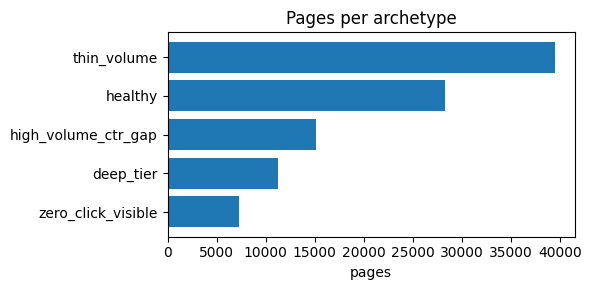

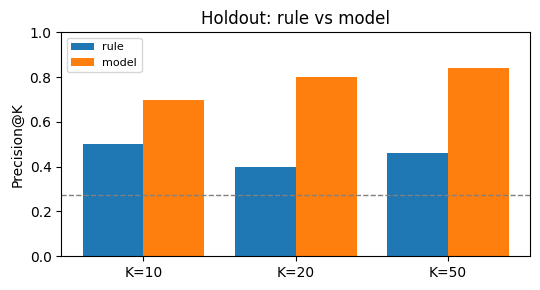

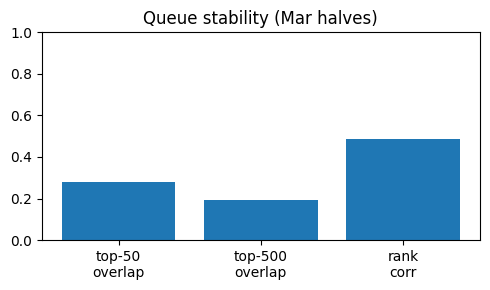


Saved → work\outputs\playbook_metrics.json
Figures → work\figures/
Queue CSV (not committed) → work\outputs\action_playbook_queue.csv


In [21]:
OUT = ROOT / "work" / "outputs"
FIG = ROOT / "work" / "figures"
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

# Ranked queue (gitignored — regenerated by this notebook)
export_cols = [
    "queue_rank", "content_hash_id", "client_hash_id",
    "imp_mar", "ctr_mar", "pos_avg_mar", "position_tier",
    "model_score", "archetype", "action", "reason_code", LABEL,
]
queue_path = OUT / "action_playbook_queue.csv"
queue[export_cols].to_csv(queue_path, index=False)
print(f"Wrote {len(queue):,} rows → {queue_path.name}")

# Figures
fig, ax = plt.subplots(figsize=(6, 3))
plot = mix.dropna(subset=["pages"]).sort_values("pages")
ax.barh(plot.index, plot["pages"])
ax.set_xlabel("pages")
ax.set_title("Pages per archetype")
fig.tight_layout()
fig.savefig(FIG / "w07_archetype_mix.png", dpi=120, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(5.5, 3))
ks = [10, 20, 50]
x = np.arange(len(ks))
ax.bar(x - 0.2, [bench.loc["ML-07 rule (ctr_gap)", f"P@{k}"] for k in ks], 0.4, label="rule")
ax.bar(x + 0.2, [bench.loc["ML-08 model", f"P@{k}"] for k in ks], 0.4, label="model")
ax.axhline(holdout["base_rate"], ls="--", color="grey", lw=1)
ax.set_xticks(x)
ax.set_xticklabels([f"K={k}" for k in ks])
ax.set_ylabel("Precision@K")
ax.set_ylim(0, 1)
ax.set_title("Holdout: rule vs model")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG / "w07_precision_at_k.png", dpi=120, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(5, 3))
vals = [decay["top_50_overlap"], decay["top_500_overlap"], decay["rank_corr"]]
ax.bar(["top-50\noverlap", "top-500\noverlap", "rank\ncorr"], vals)
ax.set_ylim(0, 1)
ax.set_title("Queue stability (Mar halves)")
fig.tight_layout()
fig.savefig(FIG / "w07_queue_stability.png", dpi=120, bbox_inches="tight")
plt.show()

# Metrics JSON (commit this — paper receipts)
payload = {
    "lane": "Lane 4 CTR opportunity",
    "slice": "month=2026-03",
    "label": LABEL,
    "features": FEATURE_COLS,
    "n_pages": int(len(queue)),
    "honest_holdout": holdout,
    "benchmarks": bench.reset_index().to_dict(orient="records"),
    "archetype_mix": mix.reset_index().dropna(subset=["pages"]).to_dict(orient="records"),
    "decay": decay,
    "minutes_per_review_assumption": MINUTES,
    "no_go": NO_GO,
}
metrics_path = OUT / "playbook_metrics.json"
metrics_path.write_text(json.dumps(payload, indent=2))
print(f"\nSaved → {metrics_path.relative_to(ROOT)}")
print(f"Figures → {FIG.relative_to(ROOT)}/")
print(f"Queue CSV (not committed) → {queue_path.relative_to(ROOT)}")


## Self-check

Before you submit, confirm each line honestly:

- [X] Every section above is filled — markdown thinking AND the code that backs it
- [X] The notebook runs top to bottom with no errors (Runtime → Run all)
- [X] No client names, URLs, or private queries anywhere
- [X] My claims use careful words: observed, measured, directional, decision-support
- [X] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.